#  Milestone 1: Data Loading, Cleaning & Initial EDA
**Project:** US Natural Disaster Declarations — Visual Analytics  
**Dataset:** `database.csv` (FEMA Disaster Declarations, 46,185 records)  
**Goal:** Load the raw CSV, clean it, and save a processed version for further analysis.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Raw Data

In [2]:
RAW_PATH = '../data/raw/database.csv'

df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print('\nColumns:', list(df_raw.columns))
df_raw.head()

Loaded: 46,185 rows × 14 columns

Columns: ['Declaration Number', 'Declaration Type', 'Declaration Date', 'State', 'County', 'Disaster Type', 'Disaster Title', 'Start Date', 'End Date', 'Close Date', 'Individual Assistance Program', 'Individuals & Households Program', 'Public Assistance Program', 'Hazard Mitigation Program']


,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


## 3. Initial Exploration

In [3]:
print('=== Dataset Info ===')
df_raw.info()
print('\n=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Declaration Number                46185 non-null  object
 1   Declaration Type                  46185 non-null  object
 2   Declaration Date                  46185 non-null  object
 3   State                             46185 non-null  object
 4   County                            45988 non-null  object
 5   Disaster Type                     46185 non-null  object
 6   Disaster Title                    46185 non-null  object
 7   Start Date                        46185 non-null  object
 8   End Date                          45843 non-null  object
 9   Close Date                        35210 non-null  object
 10  Individual Assistance Program     46185 non-null  object
 11  Individuals & Households Program  46185 non-null  object
 1

In [4]:
print('=== Value Counts — Disaster Type ===')
print(df_raw['Disaster Type'].value_counts())
print('\n=== Value Counts — Declaration Type ===')
print(df_raw['Declaration Type'].value_counts())
print('\n=== Unique States ===')
print(sorted(df_raw['State'].dropna().unique()))

=== Value Counts — Disaster Type ===
Disaster Type
Storm              16250
Flood               9317
Hurricane           8764
Snow                3565
Fire                2647
Ice                 1970
Tornado             1412
Drought             1292
Winter               301
Other                297
Typhoon              119
Earthquake           105
Volcano               50
Water                 42
Chemical              18
Mud/Landslide         10
Tsunami                9
Dam/Levee Break        6
Human Cause            6
Terrorism              5
Name: count, dtype: int64

=== Value Counts — Declaration Type ===
Declaration Type
Disaster     33630
Emergency    11520
Fire          1035
Name: count, dtype: int64

=== Unique States ===
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'FM', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MH', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 

## 4. Data Cleaning

In [5]:
df = df_raw.copy()

# ── Parse date columns ──
for col in ['Declaration Date', 'Start Date', 'End Date', 'Close Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


# ── Drop rows missing critical fields ──
critical = ['Declaration Date', 'Disaster Type', 'State']
before = len(df)
df.dropna(subset=critical, inplace=True)
print(f'Dropped {before - len(df)} rows with missing critical fields ✅')

# ── Remove duplicates ──
df.drop_duplicates(inplace=True)

# ── Strip whitespace from string columns ──
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f'Final shape: {df.shape} ')
df.head()

Dropped 0 rows with missing critical fields ✅
Final shape: (46185, 14) 


,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,1953-05-02,GA,NaN,Tornado,Tornado,1953-05-02,1953-05-02,1954-06-01,Yes,No,Yes,Yes
1,DR-2,Disaster,1953-05-15,TX,NaN,Tornado,Tornado and Heavy Rainfall,1953-05-15,1953-05-15,1958-01-01,Yes,No,Yes,Yes
2,DR-3,Disaster,1953-05-29,LA,NaN,Flood,Flood,1953-05-29,1953-05-29,1960-02-01,Yes,No,Yes,Yes
3,DR-4,Disaster,1953-06-02,MI,NaN,Tornado,Tornado,1953-06-02,1953-06-02,1956-02-01,Yes,No,Yes,Yes
4,DR-5,Disaster,1953-06-06,MT,NaN,Flood,Floods,1953-06-06,1953-06-06,1955-12-01,Yes,No,Yes,Yes


In [6]:
# ── Extract temporal features ──
df['Year']       = df['Declaration Date'].dt.year
df['Month']      = df['Declaration Date'].dt.month
df['Month_Name'] = df['Declaration Date'].dt.strftime('%b')
df['Quarter']    = df['Declaration Date'].dt.quarter

def get_season(m):
    if m in [12,1,2]: return 'Winter'
    elif m in [3,4,5]: return 'Spring'
    elif m in [6,7,8]: return 'Summer'
    else: return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df['Decade'] = (df['Year'] // 10) * 10


df[['Declaration Date', 'Year', 'Month', 'Month_Name', 'Season', 'Decade']].head()

,Declaration Date,Year,Month,Month_Name,Season,Decade
0,1953-05-02,1953,5,May,Spring,1950
1,1953-05-15,1953,5,May,Spring,1950
2,1953-05-29,1953,5,May,Spring,1950
3,1953-06-02,1953,6,Jun,Summer,1950
4,1953-06-06,1953,6,Jun,Summer,1950


## 5. Quick EDA Visualizations

C:\Users\vijay\AppData\Local\Temp\ipykernel_14640\813829760.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_types.values, y=top_types.index, palette='viridis', ax=ax)


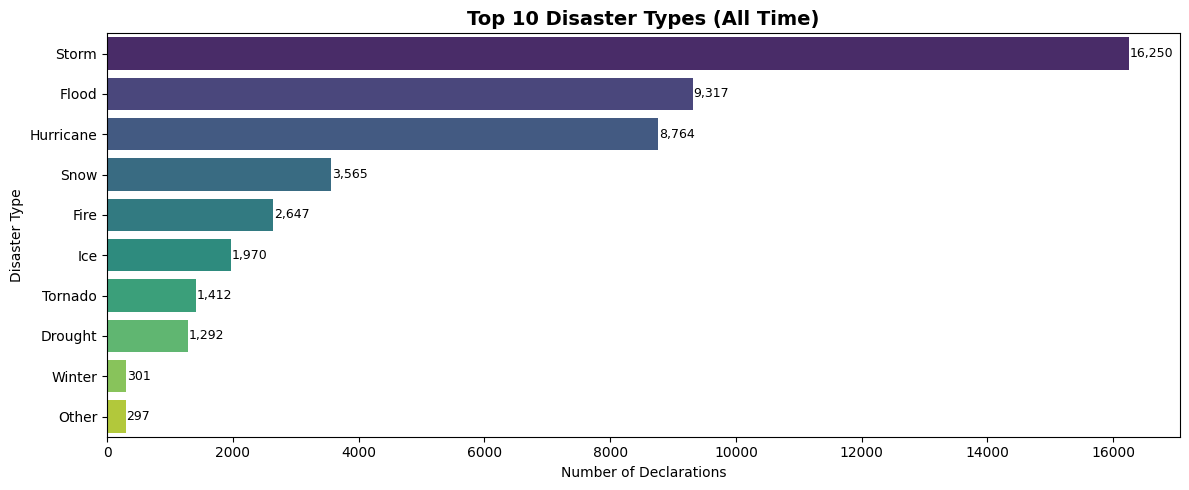

In [7]:

import os


os.makedirs('../visualizations', exist_ok=True)

# Top Disaster Types
top_types = df['Disaster Type'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_types.values, y=top_types.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Disaster Types (All Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Declarations')
for i, v in enumerate(top_types.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visualizations/top10_disaster_types.png', dpi=150)
plt.show()


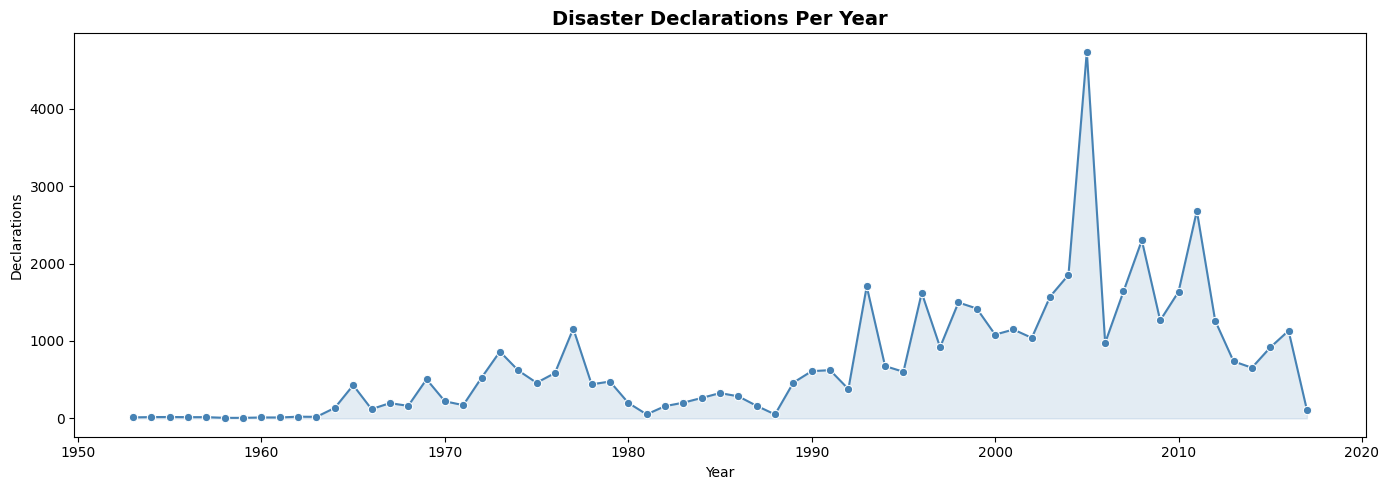

In [8]:
# Declarations per Year
yearly = df.groupby('Year').size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=yearly, x='Year', y='Count', marker='o', color='steelblue', ax=ax)
ax.fill_between(yearly['Year'], yearly['Count'], alpha=0.15, color='steelblue')
ax.set_title('Disaster Declarations Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Declarations')
plt.tight_layout()
plt.savefig('../visualizations/declarations_per_year.png', dpi=150)
plt.show()

## 6. Save Cleaned Data

In [9]:
os.makedirs('../data/processed', exist_ok=True)
SAVE_PATH = '../data/processed/fema_clean.csv'
df.to_csv(SAVE_PATH, index=False)
print(f' Cleaned data saved → {SAVE_PATH}')
print(f'   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

PermissionError: [Errno 13] Permission denied: '../data/processed/fema_clean.csv'

---
## ✅ Milestone 1 Complete
| Step | Status |
|------|--------|
| Raw data loaded (`database.csv`) | ✅ |
| Dates parsed, missing values handled | ✅ |
| Temporal features derived (Year, Month, Season, Decade) | ✅ |
| Cleaned data saved to `data/processed/fema_clean.csv` | ✅ |

**Next →** Open `02_temporal_analysis.ipynb`